In [1]:
#Code 6 (Uses SVI-integrated dataset to run XGBoost Classification)
# HIGH_RISK_CUTOFF is the manual % threshold for defining "high risk" based on counties with the highest Access Disruption Risk Index (ADRI).
# Code selects features (features_to_use), validates dataset, separates features (X) from target (y, representing the top counties w highest ADRI), creates training/test sets
# Either run 5a (to optimize hyperparameters) or 5b (set final hyperparameters) and then update how "importance" is defined (in code block 6). If running GSCV, set it to "best_model"; if setting final parameters, set to "final_model"
# Ultimately, update 5b with results from 5a and rerun it (or use the results from XGBoost from running 5b where final hyperparameters are set)
# The results are different, because GSCV uses cross validation (thus splitting training set into smaller datasets to tune parameters) whereas setting final hyperparameters allows XGBoost to access the 100% full training set.
# df is ultimately exported to final_risk_predictions.xlsx -- with Risk_Probability and Predicted_High_Risk appended.

%matplotlib inline
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel('output/master_df_with_features_clusters_SVI.xlsx')
#df = pd.read_excel('output/master_df_with_features_clusters_SVI_v2_(exclude cluster3).xlsx')


In [4]:
HIGH_RISK_CUTOFF = 0.75

risk_threshold = df['Access_Disruption_Risk_Index'].quantile(HIGH_RISK_CUTOFF)
df['Target_High_Risk'] = (df['Access_Disruption_Risk_Index'] > risk_threshold).astype(int)

print(f"   -> Target Created: 'Target_High_Risk' (1 = Risk Score > {risk_threshold:.2f})")
print(f"   -> Class Balance: {df['Target_High_Risk'].value_counts(normalize=True).to_dict()}")

   -> Target Created: 'Target_High_Risk' (1 = Risk Score > 59.00)
   -> Class Balance: {0: 0.75, 1: 0.25}


In [5]:
# Select Features for Model
features_to_use = [
    # --- PLAN MIX ---
    'feat_pct_bronze', 
    'feat_pct_premium_tier',
    
    # --- COST & VALUE ---
    'avg_premium_before_APTC',  
    'feat_pct_paying_under_10',
    
    # --- MARKET BEHAVIOR ---
    'feat_net_attrition',
    'feat_market_newness',
    'feat_passive_renewal',
    
    # --- DEMOGRAPHICS ---
    'feat_pct_age_18_34',
    'feat_pct_black',
    'feat_pct_hispanic',
    'feat_pct_asian',
    'feat_pct_aian',
    'feat_pct_white',
    
    # --- CLUSTERING METRIC ---
    #'Silhouette_Score',
    
    # --- SVI FEATURES ---
    'EP_NOVEH', 'EP_LIMENG', 'EP_DISABL', 'EP_SNGPNT', 
    'EP_HBURD', 'EP_POV150', 'EP_UNEMP'
]

# Robust check
X_cols = [c for c in features_to_use if c in df.columns]
print(f"   -> Features selected for model: {len(X_cols)} / {len(features_to_use)}")
missing = set(features_to_use) - set(X_cols)
if missing:
    print(f"   ⚠️ Warning: The following features are missing and will be excluded: {missing}")

if 'Cluster' in df.columns:
    cluster_dummies = pd.get_dummies(df['Cluster'], prefix='Cluster')
    df = pd.concat([df, cluster_dummies], axis=1)
    X_cols.extend(cluster_dummies.columns.tolist())

X = df[X_cols].copy()
y = df['Target_High_Risk']

   -> Features selected for model: 20 / 20


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
# ---------------------------------------------------------
# 5a. Hyperparameter Tuning
# ---------------------------------------------------------
print("\n--- 2. Tuning Hyperparameters ---")
neg_count, pos_count = np.bincount(y_train)
scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1

param_grid = {
    'max_depth': [7, 9, 11, 13],
    'learning_rate': [0.005, 0.01, 0.05, 0.1],
    'n_estimators': [400, 600, 800, 1000],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'scale_pos_weight': [scale_pos_weight]
}

xgb_clf = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False)

grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"   -> Best Parameters: {grid_search.best_params_}")
print(f"   -> Best ROC-AUC Score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_  #uncomment if re-running GridSearchCV
y_pred = best_model.predict(X_test)        #uncomment if re-running GridSearchCV
y_prob = best_model.predict_proba(X_test)[:, 1]    #uncomment if re-running GridSearchCV


--- 2. Tuning Hyperparameters ---
Fitting 3 folds for each of 64 candidates, totalling 192 fits


C:\Users\liuh102\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:199: UserWarning: [08:37:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\liuh102\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:199: UserWarning: [08:37:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\liuh102\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:199: UserWarning: [08:37:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encod

   -> Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 11, 'n_estimators': 800, 'scale_pos_weight': np.float64(3.0), 'subsample': 0.8}
   -> Best ROC-AUC Score: 0.8610


In [9]:
# ---------------------------------------------------------
# 5b. Set Final Hyperparameters based on GridSearchCV
# ---------------------------------------------------------

# Best parameters found in GridSearchCV
final_params = {
    'colsample_bytree': 0.8, 
    'learning_rate': 0.01,    # Slow learning
    'max_depth': 11,           # Shallow/Explainable trees
    'n_estimators': 800,     # Robust count
    'scale_pos_weight': 3.0,  # Handling imbalance
    'subsample': 0.8, 
    'objective': 'binary:logistic', 
    'eval_metric': 'logloss', 
    'random_state': 42
}

final_model = xgb.XGBClassifier(**final_params)
final_model.fit(X_train, y_train)

y_prob = final_model.predict_proba(X_test)[:, 1]
y_pred = final_model.predict(X_test)


--- 3. Model Evaluation (Test Set) ---
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       324
           1       0.64      0.65      0.65       108

    accuracy                           0.82       432
   macro avg       0.76      0.76      0.76       432
weighted avg       0.82      0.82      0.82       432

Test ROC-AUC: 0.8675


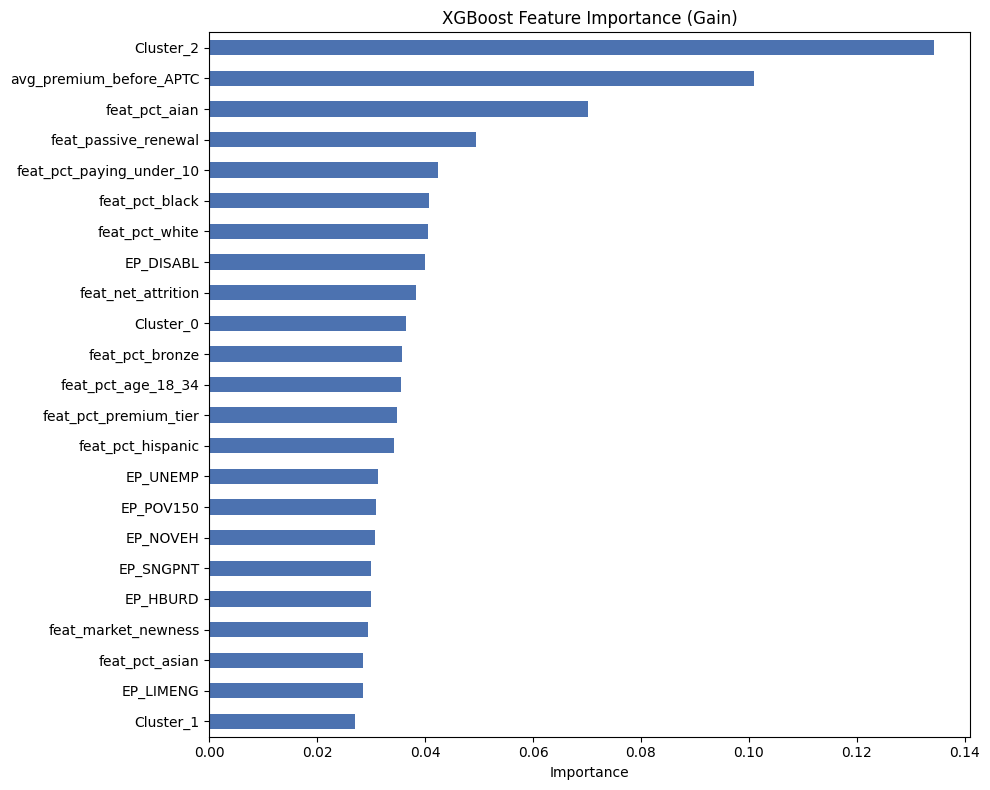

In [10]:
# ---------------------------------------------------------
# 6. Evaluation
# ---------------------------------------------------------

print("\n--- 3. Model Evaluation (Test Set) ---")
print(classification_report(y_test, y_pred))
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

# Append predictions to the full dataframe
#df['Risk_Probability'] = final_model.predict_proba(X[X_cols])[:, 1]
#df['Predicted_High_Risk'] = final_model.predict(X[X_cols])
#df = df.drop(columns=['Cluster_0','Cluster_1','Cluster_2','Cluster_3'])

#importance = best_model.feature_importances_ # Uncomment if rerunning GridSearchCV and defining importance based on GSCV results
importance = final_model.feature_importances_ # Run this if using final_params
feat_imp = pd.Series(importance, index=X_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feat_imp.plot(kind='barh', color='#4c72b0')
plt.title('XGBoost Feature Importance (Gain)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [17]:
#df.to_excel('output/final_risk_predictions.xlsx', index=False)
df.to_excel('output/final_risk_predictions_v2_(exclude cluster3)_(threshold).xlsx', index=False)

In [11]:
feat_imp

Cluster_1                   0.027099
EP_LIMENG                   0.028449
feat_pct_asian              0.028566
feat_market_newness         0.029439
EP_HBURD                    0.029932
EP_SNGPNT                   0.030039
EP_NOVEH                    0.030735
EP_POV150                   0.030915
EP_UNEMP                    0.031296
feat_pct_hispanic           0.034239
feat_pct_premium_tier       0.034716
feat_pct_age_18_34          0.035594
feat_pct_bronze             0.035769
Cluster_0                   0.036523
feat_net_attrition          0.038266
EP_DISABL                   0.039976
feat_pct_white              0.040585
feat_pct_black              0.040807
feat_pct_paying_under_10    0.042314
feat_passive_renewal        0.049415
feat_pct_aian               0.070169
avg_premium_before_APTC     0.100875
Cluster_2                   0.134284
dtype: float32